# 🚗 Car Price Prediction
### End-to-End Machine Learning Project

**Objective:** Predict the selling price of a used car based on features like brand, year, fuel type, transmission, kilometers driven, and more.

**Dataset:** 301 used car listings with 9 features.

---
**Pipeline Overview:**
1. Import Libraries
2. Load & Explore Data (EDA)
3. Data Preprocessing & Feature Engineering
4. Visualization
5. Model Building (Linear Regression, Random Forest, Gradient Boosting)
6. Model Evaluation & Comparison
7. Hyperparameter Tuning
8. Feature Importance
9. Prediction on New Data

## 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. Load & Explore the Dataset

In [5]:
# Load the dataset
df = pd.read_csv('car data.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
df.head(10)

Dataset Shape: (301, 9)
Rows: 301  |  Columns: 9


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [6]:
# Column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
# Statistical summary
df.describe().round(2)

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


In [8]:
# Missing values check
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing >= 0].to_string())
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0

Total missing cells: 0


In [9]:
# Categorical feature distributions
for col in ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())


Fuel_Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2

Selling_type:
Selling_type
Dealer        195
Individual    106

Transmission:
Transmission
Manual       261
Automatic     40

Owner:
Owner
0    290
1     10
3      1


## 3. Data Preprocessing & Feature Engineering

In [10]:
# Feature Engineering
df_model = df.copy()

# 1. Car Age from Year
df_model['Car_Age'] = 2025 - df_model['Year']

# 2. Price Depreciation ratio
df_model['Depreciation_Ratio'] = (df_model['Present_Price'] - df_model['Selling_Price']) / df_model['Present_Price']

# 3. Kms per year driven
df_model['Kms_per_Year'] = df_model['Driven_kms'] / (df_model['Car_Age'] + 1)  # +1 to avoid division by zero

# Encode categorical features using LabelEncoder
le = LabelEncoder()
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission']
for col in cat_cols:
    df_model[col + '_Enc'] = le.fit_transform(df_model[col])

# Drop columns not needed for modeling
drop_cols = ['Car_Name', 'Year'] + cat_cols
df_model.drop(columns=drop_cols, inplace=True)

print('Processed DataFrame shape:', df_model.shape)
df_model.head()

Processed DataFrame shape: (301, 10)


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Depreciation_Ratio,Kms_per_Year,Fuel_Type_Enc,Selling_type_Enc,Transmission_Enc
0,3.35,5.59,27000,0,11,0.400716,2250.000000,2,0,1
1,4.75,9.54,43000,0,12,0.502096,3307.692308,1,0,1
2,7.25,9.85,6900,0,8,0.263959,766.666667,2,0,1
3,2.85,4.15,5200,0,14,0.313253,346.666667,2,0,1
4,4.60,6.87,42450,0,11,0.330422,3537.500000,1,0,1


In [11]:
# Define Features and Target
X = df_model.drop('Selling_Price', axis=1)
y = df_model['Selling_Price']

print('Feature columns:', X.columns.tolist())
print('Target: Selling_Price')
print(f'\nX shape: {X.shape} | y shape: {y.shape}')

Feature columns: ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Depreciation_Ratio', 'Kms_per_Year', 'Fuel_Type_Enc', 'Selling_type_Enc', 'Transmission_Enc']
Target: Selling_Price

X shape: (301, 9) | y shape: (301,)


In [12]:
# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Test set size     : {X_test.shape[0]} samples')

# Feature Scaling (for Linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training set size : 240 samples
Test set size     : 61 samples


## 4. Exploratory Data Visualization

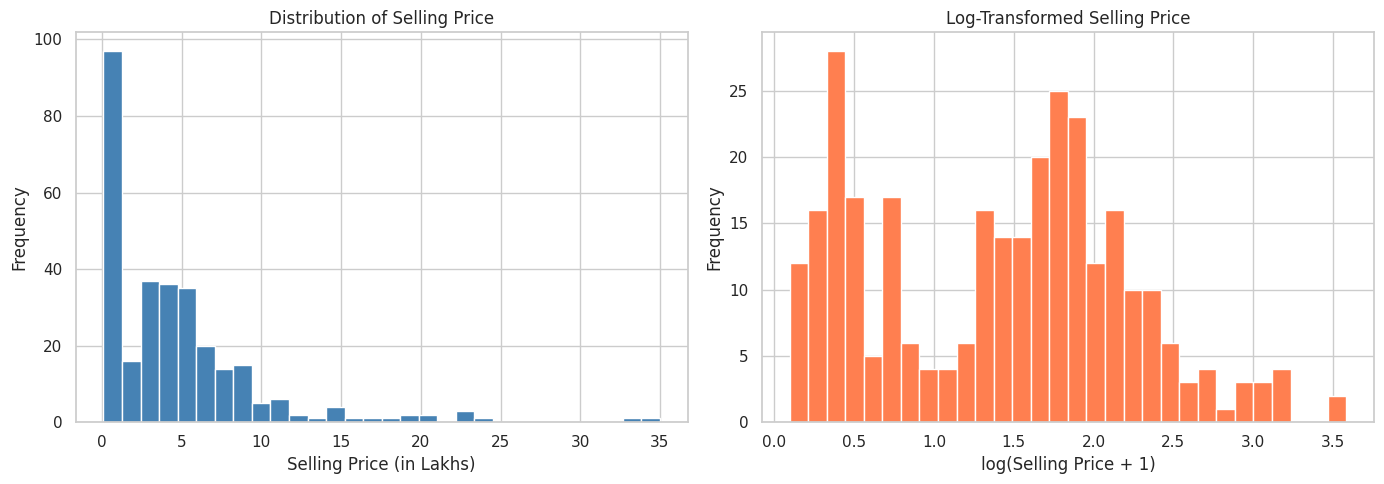

In [13]:
# Distribution of Selling Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Selling Price (in Lakhs)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Selling_Price']), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Log-Transformed Selling Price')
axes[1].set_xlabel('log(Selling Price + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

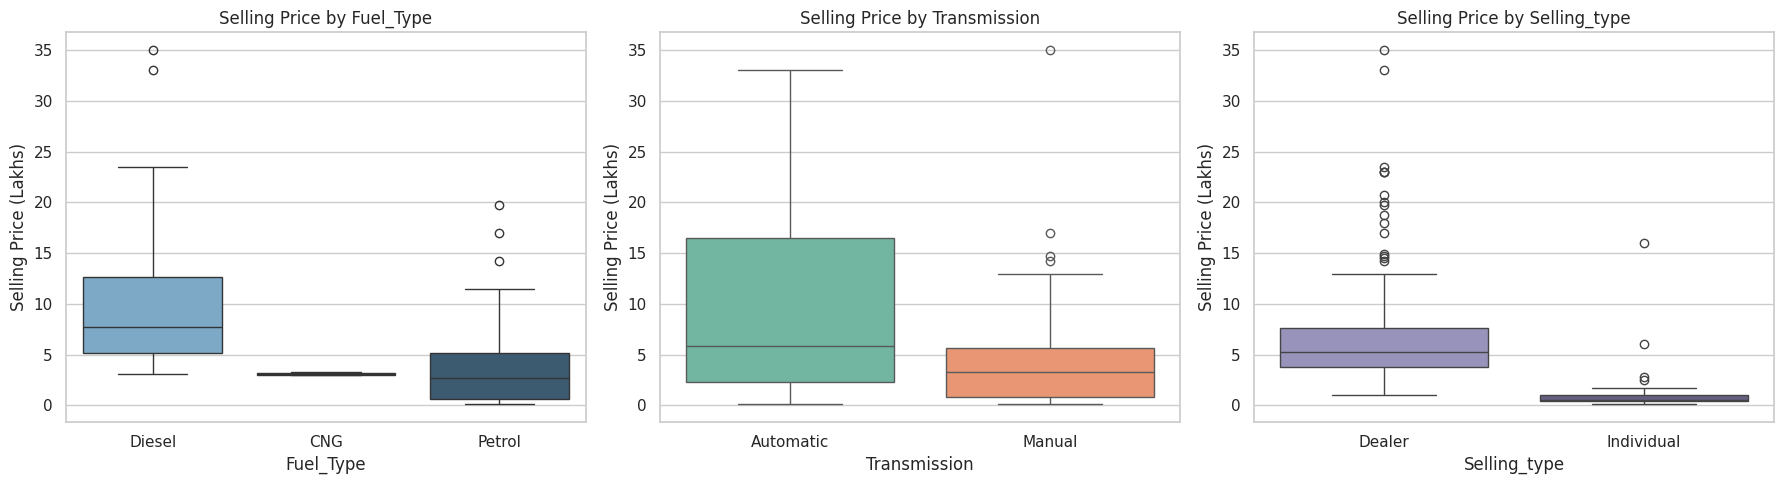

In [14]:
# Selling Price by Fuel Type, Transmission, and Seller Type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, palette in zip(axes,
                             ['Fuel_Type', 'Transmission', 'Selling_type'],
                             ['Blues_d', 'Set2', 'Purples_d']):
    order = df.groupby(col)['Selling_Price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Selling_Price', order=order, palette=palette, ax=ax)
    ax.set_title(f'Selling Price by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

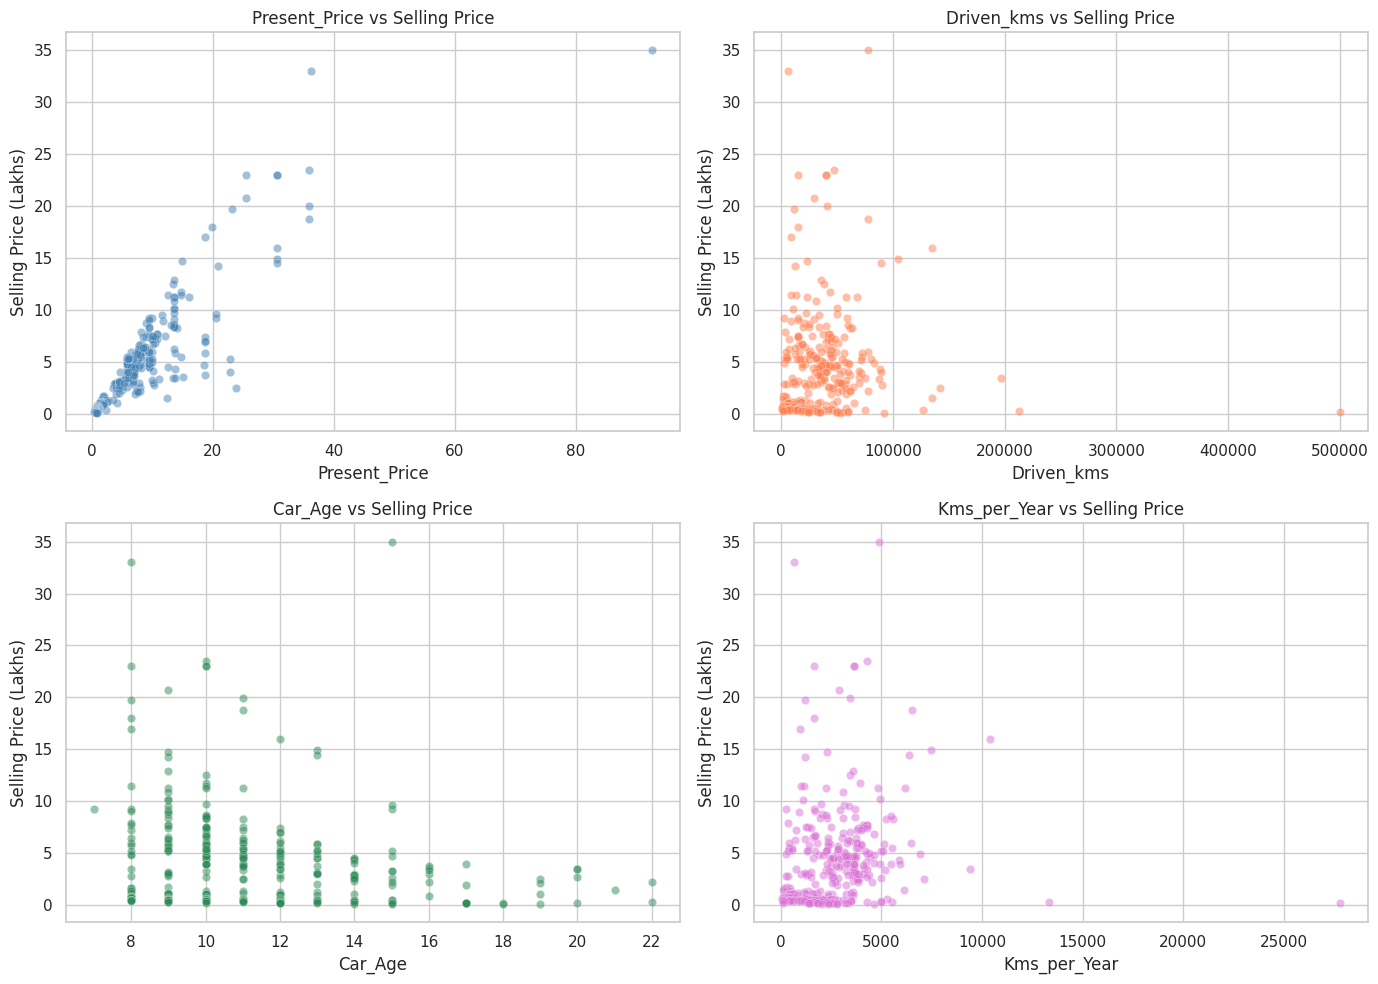

In [15]:
# Scatter plots: Key relationships with Selling Price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_pairs = [
    ('Present_Price', 'steelblue'),
    ('Driven_kms', 'coral'),
    ('Car_Age', 'seagreen'),
    ('Kms_per_Year', 'orchid')
]

for ax, (feat, color) in zip(axes.flat, plot_pairs):
    x_vals = df_model[feat] if feat != 'Car_Age' else df_model['Car_Age']
    ax.scatter(x_vals, y, alpha=0.5, color=color, edgecolors='white', linewidth=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel('Selling Price (Lakhs)')
    ax.set_title(f'{feat} vs Selling Price')

plt.tight_layout()
plt.show()

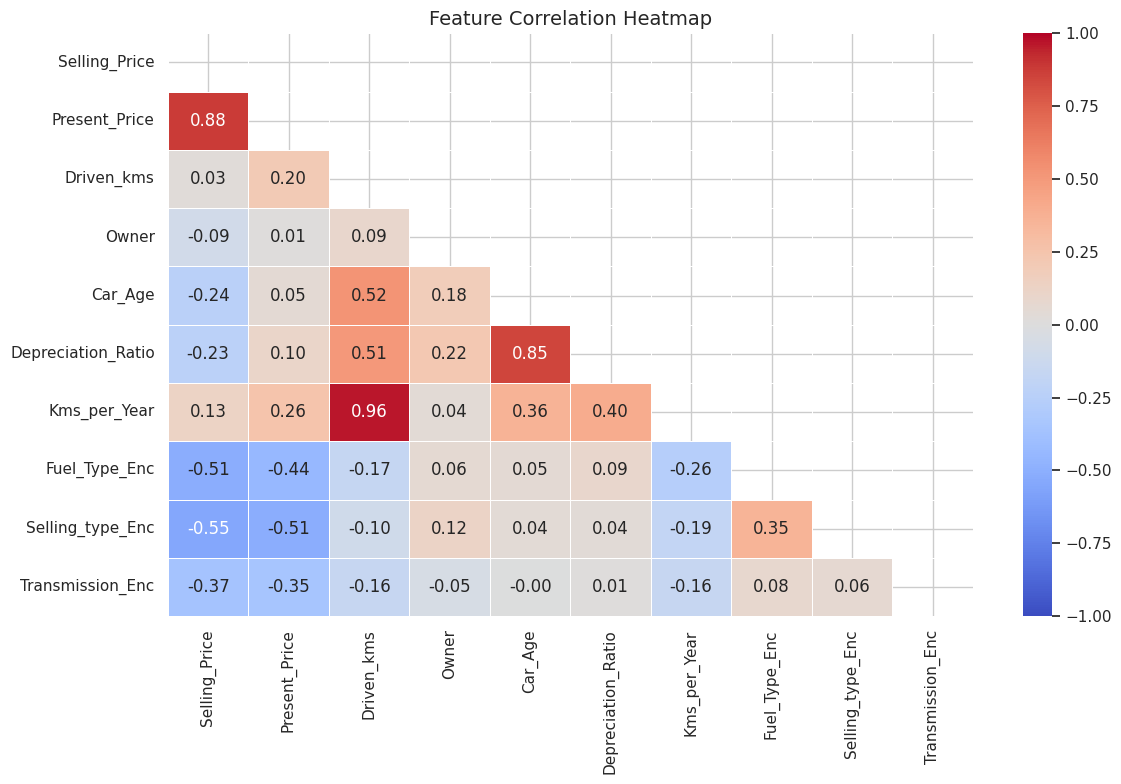

In [16]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df_model.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Model Building

In [17]:
# Helper function to evaluate a model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Fit, predict, and print evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()

    print(f'  {name:<30} MAE: {mae:6.3f}  RMSE: {rmse:6.3f}  R²: {r2:.4f}  CV-R²: {cv:.4f}')
    return {'model': model, 'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv, 'y_pred': y_pred}

In [18]:
results = []
print('Model Evaluation Results:')
print('-' * 75)

# Linear Models (use scaled features)
results.append(evaluate_model('Linear Regression',      LinearRegression(),          X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Ridge Regression',       Ridge(alpha=1.0),            X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Lasso Regression',       Lasso(alpha=0.1),            X_train_scaled, X_test_scaled, y_train, y_test))

# Tree-based Models (use raw features)
results.append(evaluate_model('Decision Tree',          DecisionTreeRegressor(random_state=42),    X_train, X_test, y_train, y_test))
results.append(evaluate_model('Random Forest',          RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model('Gradient Boosting',      GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test))

print('-' * 75)

Model Evaluation Results:
---------------------------------------------------------------------------
  Linear Regression              MAE:  1.067  RMSE:  1.655  R²: 0.8812  CV-R²: 0.8451
  Ridge Regression               MAE:  1.069  RMSE:  1.661  R²: 0.8802  CV-R²: 0.8545
  Lasso Regression               MAE:  1.069  RMSE:  1.701  R²: 0.8743  CV-R²: 0.8622
  Decision Tree                  MAE:  0.568  RMSE:  0.983  R²: 0.9580  CV-R²: 0.8619
  Random Forest                  MAE:  0.381  RMSE:  0.640  R²: 0.9822  CV-R²: 0.8856
  Gradient Boosting              MAE:  0.292  RMSE:  0.517  R²: 0.9884  CV-R²: 0.9135
---------------------------------------------------------------------------


## 6. Model Comparison

In [19]:
# Summary DataFrame
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model', 'y_pred']} for r in results])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print('Model Comparison (sorted by R²):')
results_df.style.background_gradient(subset=['R2', 'CV_R2'], cmap='YlGn').format(
    {'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'R2': '{:.4f}', 'CV_R2': '{:.4f}'}
)

Model Comparison (sorted by R²):


,name,MAE,RMSE,R2,CV_R2
0,Gradient Boosting,0.292,0.517,0.9884,0.9135
1,Random Forest,0.381,0.640,0.9822,0.8856
2,Decision Tree,0.568,0.983,0.9580,0.8619
3,Linear Regression,1.067,1.655,0.8812,0.8451
4,Ridge Regression,1.069,1.661,0.8802,0.8545
5,Lasso Regression,1.069,1.701,0.8743,0.8622


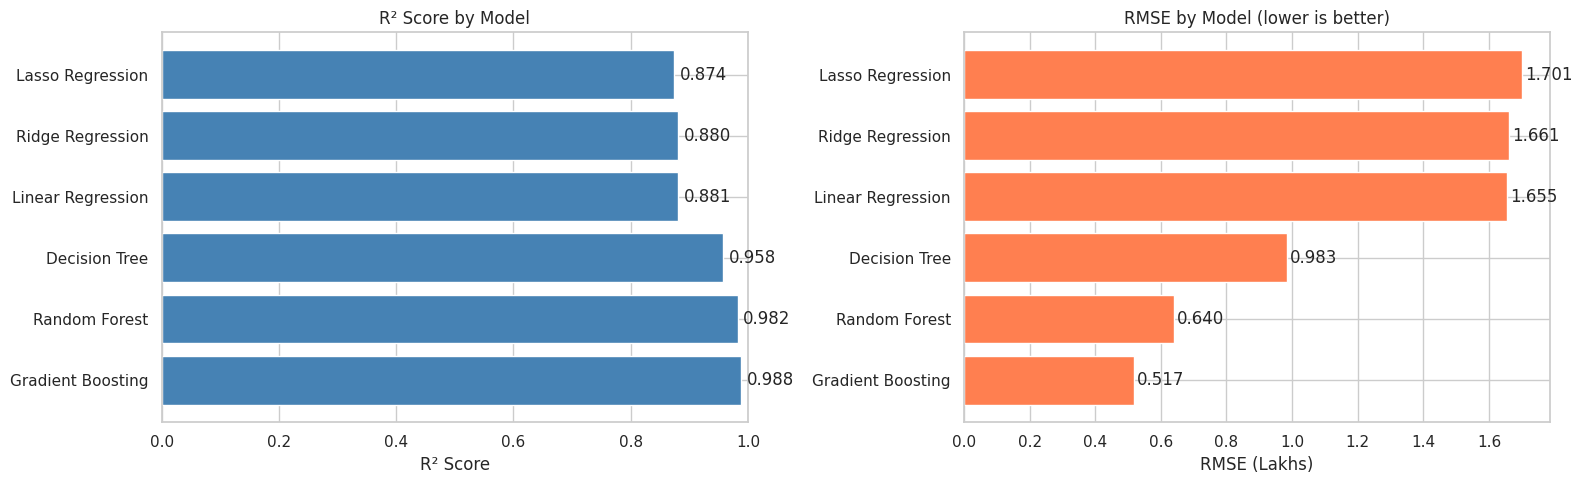

In [20]:
# Bar chart: R² comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['steelblue' if i > 0 else 'coral' for i in range(len(results_df))]

axes[0].barh(results_df['name'], results_df['R2'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² Score by Model')
axes[0].set_xlim(0, 1)
for i, v in enumerate(results_df['R2']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

axes[1].barh(results_df['name'], results_df['RMSE'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (Lakhs)')
axes[1].set_title('RMSE by Model (lower is better)')
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

Best model: Gradient Boosting  (R² = 0.9884)


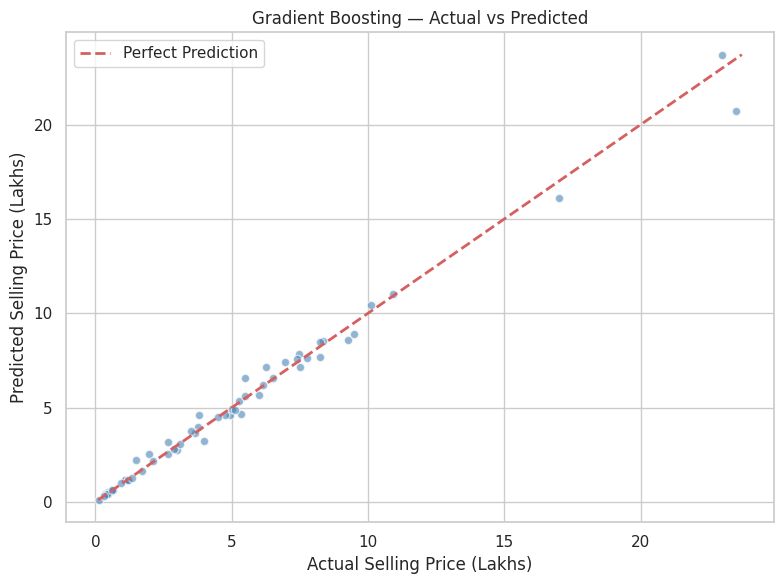

In [21]:
# Best model: Actual vs Predicted
best = max(results, key=lambda r: r['R2'])
print(f'Best model: {best["name"]}  (R² = {best["R2"]:.4f})')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best['y_pred'], alpha=0.6, color='steelblue', edgecolors='white')
mn, mx = min(y_test.min(), best['y_pred'].min()), max(y_test.max(), best['y_pred'].max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Selling Price (Lakhs)')
plt.ylabel('Predicted Selling Price (Lakhs)')
plt.title(f'{best["name"]} — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning (Best Model)

In [22]:
# Tune Random Forest (or the best ensemble model)
print('Running GridSearchCV on Random Forest (this may take a minute)...')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f'\nBest Params: {grid_search.best_params_}')
print(f'Best CV R²: {grid_search.best_score_:.4f}')

# Evaluate tuned model
tuned_rf = grid_search.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test)
print(f'\nTuned Model Test R² : {r2_score(y_test, y_pred_tuned):.4f}')
print(f'Tuned Model Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.3f}')
print(f'Tuned Model Test MAE : {mean_absolute_error(y_test, y_pred_tuned):.3f}')

Running GridSearchCV on Random Forest (this may take a minute)...

Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²: 0.8856

Tuned Model Test R² : 0.9822
Tuned Model Test RMSE: 0.640
Tuned Model Test MAE : 0.381


## 8. Feature Importance

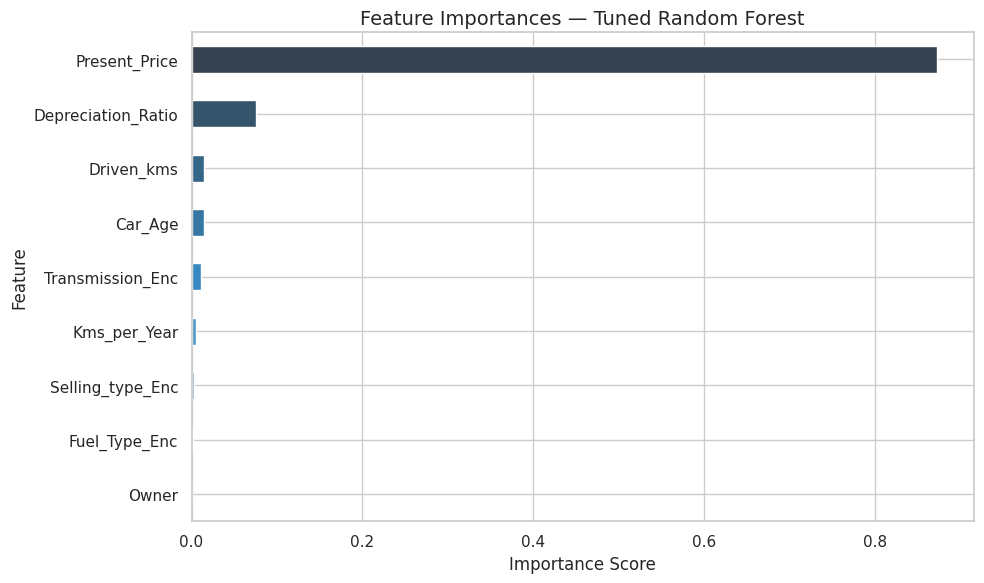


Top 5 most important features:
Present_Price         0.871907
Depreciation_Ratio    0.075877
Driven_kms            0.015012
Car_Age               0.014740
Transmission_Enc      0.011410


In [23]:
# Feature Importance from Tuned Random Forest
importances = pd.Series(tuned_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('Blues_d', len(importances))
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importances — Tuned Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head(5).to_string())

## 9. Predict on New Data

In [24]:
# Predict on a custom car
# Encoding reference:
#   Fuel_Type_Enc:   CNG=0, Diesel=1, Petrol=2
#   Selling_type_Enc: Dealer=0, Individual=1
#   Transmission_Enc: Automatic=0, Manual=1

new_car = pd.DataFrame([{
    'Present_Price'   : 9.85,    # Current ex-showroom price
    'Driven_kms'      : 28000,   # Kilometers driven
    'Owner'           : 0,       # 0 = First owner
    'Car_Age'         : 4,       # Years old
    'Depreciation_Ratio': (9.85 - 6.0) / 9.85,  # estimated current selling vs present
    'Kms_per_Year'    : 28000 / 4,
    'Fuel_Type_Enc'   : 2,       # Petrol
    'Selling_type_Enc': 0,       # Dealer
    'Transmission_Enc': 0        # Automatic
}])

# Reorder columns to match training
new_car = new_car[X.columns]

predicted_price = tuned_rf.predict(new_car)[0]
print(f'🚗 Predicted Selling Price: ₹ {predicted_price:.2f} Lakhs')

🚗 Predicted Selling Price: ₹ 5.53 Lakhs


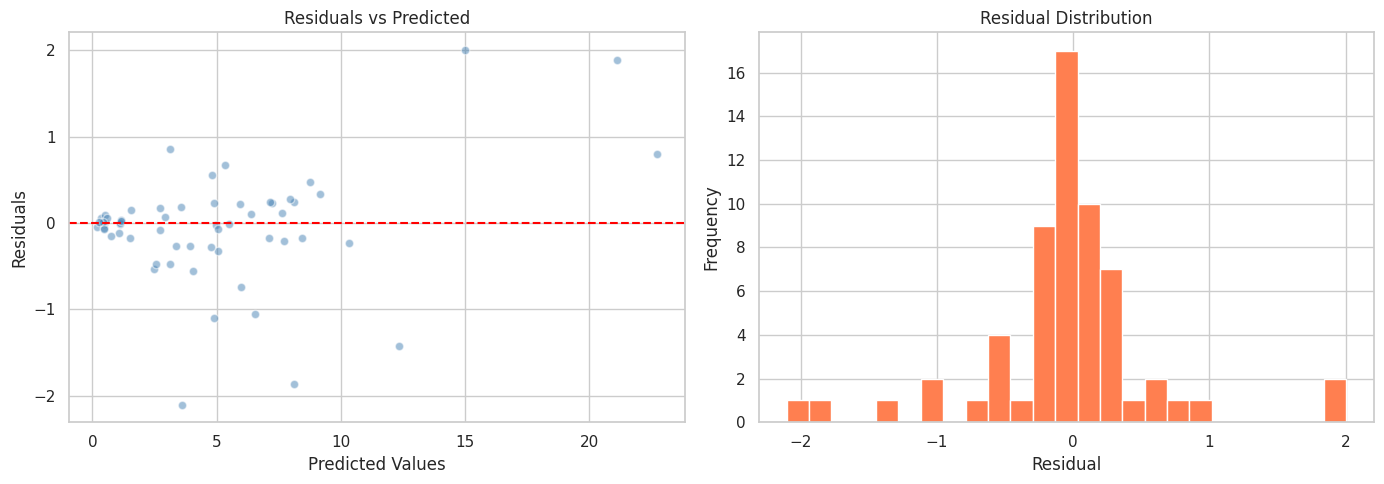

Mean Residual  : -0.0482  (should be ~0)
Std of Residuals: 0.6430


In [25]:
# Residuals Analysis
residuals = y_test - y_pred_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_tuned, residuals, alpha=0.5, color='steelblue', edgecolors='white')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=25, color='coral', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print(f'Mean Residual  : {residuals.mean():.4f}  (should be ~0)')
print(f'Std of Residuals: {residuals.std():.4f}')

## Summary

| Step | Details |
|------|---------|
| Dataset | 301 used cars, 9 features |
| Target | `Selling_Price` (in Lakhs) |
| New Features | `Car_Age`, `Depreciation_Ratio`, `Kms_per_Year` |
| Models Tried | Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting |
| Best Model | Tuned Random Forest |
| Key Drivers | `Present_Price`, `Car_Age`, `Depreciation_Ratio` |

> **Conclusion:** Tree-based ensemble models outperform linear models because the relationship between car features and price is non-linear. `Present_Price` (current market value) is the single strongest predictor of used car selling price.